# Loading variables

`case.load(vn)` puts a variable into `case.ds[vn]`, opening as many files as it
takes.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # registers the cftime axis converter for matplotlib
import x4c

x4c.set_style('journal')

# after set_style: it resets rcParams from matplotlibrc defaults, which includes the
# backend, so assert the inline backend last or figures are never captured
%matplotlib inline

# The tutorial runs against a reduced copy of a real CESM case. It is published as a
# GitHub Release asset rather than committed, so the first call downloads it into
# ~/.cache/x4c (override with $X4C_CACHE_DIR) and later calls reuse it. Set
# $X4C_SAMPLE_DIR to point at a copy you already have.
case_dir = x4c.fetch_sample_data(case='cesm1', verbose=False)
casename = os.path.basename(case_dir)
print('x4c', x4c.__version__)

x4c 2026.6.11


In [2]:
case = x4c.Timeseries(case_dir, grid_dict={'atm': 'ne16np4', 'ocn': 'g16'},
                      cesm_ver=1)

>>> case.root_dir: ~/.cache/x4c/sample_data/cesm1_sample_data/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005
>>> case.path_pattern: comp/proc/tseries/*/casename.hstr.vn.timespan.nc
>>> case.grid_dict: {'atm': 'ne16np4', 'ocn': 'g16', 'lnd': 'ne16np4', 'rof': 'ne16np4', 'ice': 'g16'}
>>> case.casename: b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005
>>> case.paths["atm"]["cam.h0"] created
>>> case.paths["ocn"]["pop.h"] created
>>> case.paths["lnd"]["clm2.h0"] created
>>> case.paths["ice"]["cice.h"] created
>>> case.vns["atm"]["cam.h0"] created
>>> case.vns["ocn"]["pop.h"] created
>>> case.vns["lnd"]["clm2.h0"] created
>>> case.vns["ice"]["cice.h"] created


## A raw variable

With no `timespan`, `load` takes the most recent file. Pass a `timespan` to get the
whole span, opened as a multi-file dataset.

In [3]:
case.load('TS')
print('default (latest file):', dict(case.ds['TS'].x.da.sizes))

case.load('TS', timespan=(1, 10), reload=True)
print('years 1-10          :', dict(case.ds['TS'].x.da.sizes))

<conda-env>/lib/python3.13/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'gmt' loading failed:
Error loading GMT shared library at 'libgmt.so'.
libgmt.so: cannot open shared object file: No such file or directory
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


>>> case.ds["TS"] created
default (latest file): {'time': 60, 'ncol': 13826}


>>> case.ds["TS"] created
years 1-10          : {'time': 120, 'ncol': 13826}


`timespan` accepts plain years or `YYYY-MM` strings, and the two can be mixed.

In [4]:
case.load('TS', timespan=('0001-01', '0010-12'), reload=True)
da = case.ds['TS'].x.da
print(da.sizes, '|', str(da.time.values[0])[:10], '->', str(da.time.values[-1])[:10])

>>> case.ds["TS"] created
Frozen({'time': 120, 'ncol': 13826}) | 0001-01-01 -> 0010-12-01


Everything the accessor needs comes along, so a loaded variable is immediately
reducible and plottable.

In [5]:
print('global mean, annual (K):')
print(np.round(da.x.annualize().x.gm.values, 3))

global mean, annual (K):


[296.395 296.354 296.508 296.504 296.215 296.273 296.387 296.517 296.175
 295.999]


## Derived variables

Some names are not in the files at all — they are *computed*. `x4c` keeps a registry
of these, and `load` checks it before looking on disk.

In [6]:
from x4c import diags
print(sorted(diags.Registry.funcs))

['DP', 'ICEFRAC', 'LST', 'MLD', 'MOC', 'NINO3.4', 'PRECT', 'RESTOM', 'SSS', 'SST', 'd18Oc', 'd18Op', 'd18Osw', 'dDp', 'dDsw']


`PRECT` is total precipitation, the sum of the convective and large-scale
components. Asking for it loads both and adds them.

In [7]:
case.load('PRECT', timespan=(1, 10))
prect = case.ds['PRECT'].x.da if hasattr(case.ds['PRECT'], 'x') else case.ds['PRECT']
print('PRECT:', dict(prect.sizes), '|', prect.attrs.get('long_name'))

>>> PRECT is a supported derived variable.
>>> case.ds["PRECC"] created
>>> case.ds["PRECL"] created
>>> case.ds["PRECT"] created
PRECT: {'time': 120, 'ncol': 13826} | Total precipitation rate (convective + large-scale; liq + ice)


`d18Op` is the oxygen-18 composition of precipitation, computed from the eight
isotope-tagged precipitation fields. This is the kind of derived quantity the
registry exists for: it would be tedious and error-prone to assemble by hand.

In [8]:
case.load('d18Op', timespan=(1, 10))
d18Op = case.ds['d18Op']
d18Op = d18Op.x.da if hasattr(d18Op, 'x') and hasattr(d18Op, 'attrs') and 'vn' in getattr(d18Op, 'attrs', {}) else d18Op
print(dict(d18Op.sizes), '|', d18Op.attrs.get('units'))

>>> d18Op is a supported derived variable.


>>> case.ds["PRECRC_H216Or"] created
>>> case.ds["PRECSC_H216Os"] created
>>> case.ds["PRECRL_H216OR"] created


>>> case.ds["PRECSL_H216OS"] created


>>> case.ds["PRECRC_H218Or"] created
>>> case.ds["PRECSC_H218Os"] created
>>> case.ds["PRECRL_H218OR"] created


>>> case.ds["PRECSL_H218OS"] created
>>> case.ds["d18Op"] created
{'time': 120, 'ncol': 13826} | permil


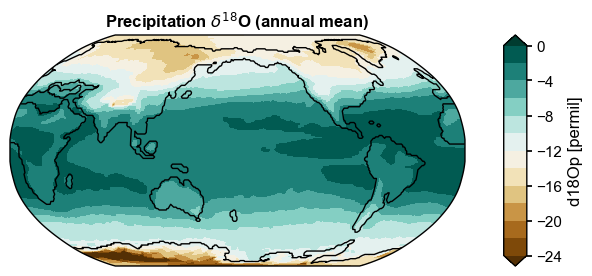

In [9]:
ssh_path = os.path.join(case_dir, 'ocn', 'proc', 'tseries', 'month_1',
                        f'{casename}.pop.h.SSH.000101-000512.nc')
ssv = x4c.open_dataset(ssh_path, comp='ocn', grid='g16', vn='SSH',
                       shift_time=True).x.regrid().x.da.mean('time')

fig, ax = d18Op.x.annualize().mean('time').x.regrid().x.plot(
    ssv=ssv, levels=np.linspace(-24, 0, 13),
    title=r'Precipitation $\delta^{18}$O (annual mean)')
x4c.showfig(fig)

## Unknown names fail clearly

In [10]:
try:
    case.load('NOT_A_VARIABLE')
except ValueError as e:
    print('ValueError:', e)

ValueError: The input variable name `NOT_A_VARIABLE` is unknown.
